In [2]:
import pandas as pd

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")


In [6]:
nav["date"] = pd.to_datetime(nav["date"])

nav["nav"] = nav["nav"].astype(float)
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [8]:
nav = nav.sort_values(
    ["amfi_code","date"]
)

In [10]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [16]:
nav.head(15)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


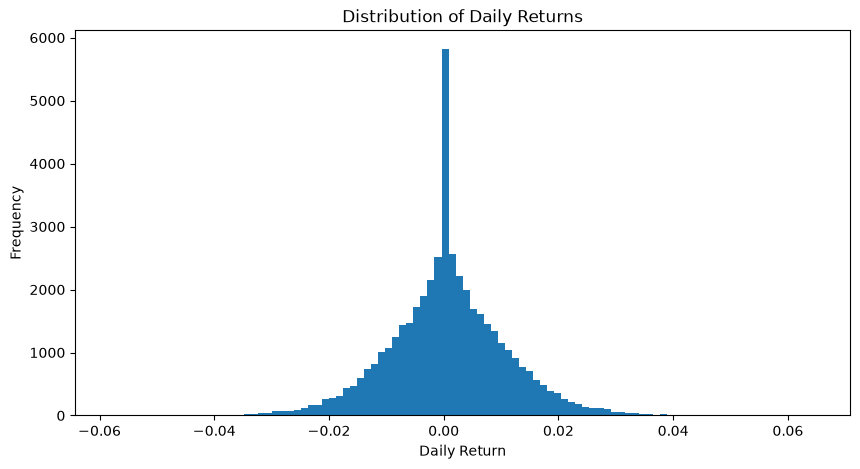

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    nav["daily_return"].dropna(),
    bins=100
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.show()

In [21]:
nav.to_csv(
    "../data/processed/nav_with_daily_returns.csv",
    index=False
)

print("Daily Returns Calculated Successfully")

Daily Returns Calculated Successfully


In [22]:

# CAGR Calculation (1Y, 3Y, 5Y)
# ============================================

import pandas as pd
import numpy as np

# Load NAV Data
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

# Convert Date
nav["date"] = pd.to_datetime(nav["date"])

# Sort Data
nav = nav.sort_values(["amfi_code", "date"])

# Latest Date in Dataset
latest_date = nav["date"].max()

# Empty List
cagr_list = []

# Loop through each fund
for amfi_code, fund_data in nav.groupby("amfi_code"):

    fund_data = fund_data.sort_values("date")

    latest_nav = fund_data.iloc[-1]["nav"]

    result = {
        "amfi_code": amfi_code
    }

    # Calculate CAGR for 1Y, 3Y, 5Y
    for years in [1, 3, 5]:

        start_date = latest_date - pd.DateOffset(years=years)

        filtered = fund_data[fund_data["date"] >= start_date]

        # Skip if enough historical data is not available
        if len(filtered) < 2:
            result[f"CAGR_{years}Y"] = np.nan
            continue

        start_nav = filtered.iloc[0]["nav"]
        end_nav = filtered.iloc[-1]["nav"]

        actual_years = (
            filtered.iloc[-1]["date"] -
            filtered.iloc[0]["date"]
        ).days / 365

        cagr = (
            (end_nav / start_nav) ** (1 / actual_years)
        ) - 1

        result[f"CAGR_{years}Y"] = round(cagr * 100, 2)

    cagr_list.append(result)

# Create DataFrame
cagr_df = pd.DataFrame(cagr_list)

# Sort by 3-Year CAGR
cagr_df = cagr_df.sort_values(
    by="CAGR_3Y",
    ascending=False
)

# Display Top Funds
print(cagr_df.head(10))

# Save CSV
cagr_df.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

print("CAGR Calculation Completed Successfully")

    amfi_code  CAGR_1Y  CAGR_3Y  CAGR_5Y
16     119094    22.26    35.07    28.19
34     148567    20.36    33.97    30.95
24     120504    13.06    32.45    23.28
2      100033    53.23    32.41    30.10
25     120505    29.60    31.74    32.80
19     119551    60.44    30.42    25.78
30     120843    26.66    29.55    30.88
36     148569    39.75    29.15    31.92
3      101206    47.92    28.94    23.52
39     149324    65.14    26.97    32.26
CAGR Calculation Completed Successfully


In [24]:

# Sharpe Ratio Calculation
# ============================================

import pandas as pd
import numpy as np

# Load NAV Data
nav = pd.read_csv("../data/processed/nav_with_daily_returns.csv")

# Remove Missing Returns
nav = nav.dropna(subset=["daily_return"])

# Annual Risk-Free Rate
risk_free_rate = 0.07

# Convert Annual Risk-Free Rate to Daily
daily_rf = risk_free_rate / 252

# Empty List
sharpe_list = []

# Calculate Sharpe Ratio for Each Fund
for amfi_code, data in nav.groupby("amfi_code"):

    avg_daily_return = data["daily_return"].mean()

    std_daily_return = data["daily_return"].std()

    annual_return = avg_daily_return * 252

    annual_std = std_daily_return * np.sqrt(252)

    sharpe = (
        annual_return - risk_free_rate
    ) / annual_std

    sharpe_list.append({
        "amfi_code": amfi_code,
        "Annual Return (%)": round(annual_return * 100,2),
        "Annual Risk (%)": round(annual_std * 100,2),
        "Sharpe Ratio": round(sharpe,2)
    })

# Create DataFrame
sharpe_df = pd.DataFrame(sharpe_list)

# Sort Highest Sharpe First
sharpe_df = sharpe_df.sort_values(
    by="Sharpe Ratio",
    ascending=False
)

# Display Top Funds
print(sharpe_df.head(10))

# Save Results
sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio Calculated Successfully")

    amfi_code  Annual Return (%)  Annual Risk (%)  Sharpe Ratio
34     148567              27.06            14.19          1.41
30     120843              27.26            15.89          1.28
36     148569              28.33            17.67          1.21
19     119551              23.10            13.74          1.17
25     120505              29.27            19.29          1.15
38     149323              26.59            17.75          1.10
2      100033              27.21            18.94          1.07
9      118632              21.80            14.15          1.05
3      101206              21.46            14.57          0.99
24     120504              21.24            14.36          0.99
Sharpe Ratio Calculated Successfully


In [26]:

# DAY 4 - TASK 4
# Sortino Ratio Calculation
# ============================================

import pandas as pd
import numpy as np

# Load NAV Data
nav = pd.read_csv("../data/processed/nav_with_daily_returns.csv")

# Remove Missing Returns
nav = nav.dropna(subset=["daily_return"])

# Annual Risk-Free Rate
risk_free_rate = 0.07

# Empty List
sortino_list = []

# Loop Through Each Fund
for amfi_code, data in nav.groupby("amfi_code"):

    # Mean Daily Return
    avg_daily_return = data["daily_return"].mean()

    # Negative Returns Only
    downside_returns = data[data["daily_return"] < 0]["daily_return"]

    # Downside Deviation
    downside_std = downside_returns.std()

    # Annual Return
    annual_return = avg_daily_return * 252

    # Annual Downside Risk
    annual_downside = downside_std * np.sqrt(252)

    # Sortino Ratio
    sortino = (
        annual_return - risk_free_rate
    ) / annual_downside

    sortino_list.append({
        "amfi_code": amfi_code,
        "Annual Return (%)": round(annual_return * 100,2),
        "Downside Risk (%)": round(annual_downside * 100,2),
        "Sortino Ratio": round(sortino,2)
    })

# Create DataFrame
sortino_df = pd.DataFrame(sortino_list)

# Highest Sortino First
sortino_df = sortino_df.sort_values(
    by="Sortino Ratio",
    ascending=False
)

# Display Top Funds
print(sortino_df.head(10))

# Save CSV
sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

print("Sortino Ratio Calculated Successfully")

    amfi_code  Annual Return (%)  Downside Risk (%)  Sortino Ratio
34     148567              27.06               8.62           2.33
30     120843              27.26               8.78           2.31
36     148569              28.33              10.17           2.10
19     119551              23.10               7.76           2.08
25     120505              29.27              11.22           1.98
38     149323              26.59              10.71           1.83
9      118632              21.80               8.27           1.79
2      100033              27.21              11.32           1.78
3      101206              21.46               8.32           1.74
24     120504              21.24               8.17           1.74
Sortino Ratio Calculated Successfully


In [28]:

# Alpha Calculation (Simplified)
# ============================================

import pandas as pd

# Load Performance Dataset
performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

# Alpha = Fund Return - Benchmark Return

performance["Alpha"] = (
    performance["return_3yr_pct"]
    -
    performance["benchmark_3yr_pct"]
)

# Select Columns
alpha_df = performance[
    [
        "amfi_code",
        "scheme_name",
        "return_3yr_pct",
        "benchmark_3yr_pct",
        "Alpha"
    ]
]

# Sort Best Alpha
alpha_df = alpha_df.sort_values(
    by="Alpha",
    ascending=False
)

print(alpha_df.head(10))

# Save CSV
alpha_df.to_csv(
    "../reports/alpha_comparison.csv",
    index=False
)

print("Alpha Calculation Completed Successfully")

    amfi_code                                        scheme_name  \
9      100025       HDFC Short Term Debt Fund - Regular - Growth   
21     120842      Kotak Emerging Equity Fund - Regular - Growth   
14     120507           ICICI Pru Liquid Fund - Regular - Growth   
22     120843             Kotak Flexicap Fund - Regular - Growth   
29     101207             ABSL Small Cap Fund - Regular - Growth   
37     149322         DSP Top 100 Equity Fund - Regular - Growth   
18     118635                     Nippon India ETF Nifty 50 BeES   
33     102887              UTI Flexi Cap Fund - Regular - Growth   
1      119552           SBI Bluechip Fund - Direct Plan - Growth   
35     148568  Mirae Asset Emerging Bluechip Fund - Regular -...   

    return_3yr_pct  benchmark_3yr_pct  Alpha  
9             7.37               5.39   1.98  
21           18.23              16.32   1.91  
14            7.68               5.83   1.85  
22           15.65              13.80   1.85  
29           22.

In [30]:
import pandas as pd

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

In [33]:
mdd_list = []
for amfi_code, data in nav.groupby("amfi_code"):
    
    data = data.sort_values("date").copy()

    # Running Peak NAV
    data["running_max"] = data["nav"].cummax()

    # Drawdown
    data["drawdown"] = (
        data["nav"] - data["running_max"]
    ) / data["running_max"]

    # Maximum Drawdown
    max_drawdown = data["drawdown"].min()

    mdd_list.append({
        "amfi_code": amfi_code,
        "Maximum Drawdown (%)": round(max_drawdown * 100, 2)
    })

In [36]:
mdd_df = pd.DataFrame(mdd_list)
mdd_df = mdd_df.sort_values(
    by="Maximum Drawdown (%)"
)

print(mdd_df.head(10))
mdd_df.to_csv(
    "../reports/maximum_drawdown.csv",
    index=False
)

print("Maximum Drawdown Calculated Successfully")

    amfi_code  Maximum Drawdown (%)
22     119599                -52.57
17     119095                -51.68
4      101207                -35.45
39     149324                -31.17
21     119598                -28.71
7      102886                -28.00
0      100016                -24.73
29     120842                -24.00
11     118634                -23.34
15     119093                -21.75
Maximum Drawdown Calculated Successfully


In [38]:

# DAY 4 - TASK 7
# FUND SCORECARD
# ============================================

import pandas as pd

# Load Reports
cagr = pd.read_csv("../reports/cagr_comparison.csv")

sharpe = pd.read_csv("../reports/sharpe_ratio.csv")

sortino = pd.read_csv("../reports/sortino_ratio.csv")

alpha = pd.read_csv("../reports/alpha_comparison.csv")

mdd = pd.read_csv("../reports/maximum_drawdown.csv")

# Merge CAGR + Sharpe
scorecard = pd.merge(
    cagr,
    sharpe[["amfi_code", "Sharpe Ratio"]],
    on="amfi_code",
    how="left"
)

# Merge Sortino
scorecard = pd.merge(
    scorecard,
    sortino[["amfi_code", "Sortino Ratio"]],
    on="amfi_code",
    how="left"
)

# Merge Alpha
scorecard = pd.merge(
    scorecard,
    alpha[["amfi_code", "Alpha"]],
    on="amfi_code",
    how="left"
)

# Merge Maximum Drawdown
scorecard = pd.merge(
    scorecard,
    mdd,
    on="amfi_code",
    how="left"
)

# Sort by Sharpe Ratio
scorecard = scorecard.sort_values(
    by="Sharpe Ratio",
    ascending=False
)

# Reset Index
scorecard.reset_index(
    drop=True,
    inplace=True
)

# Display
print(scorecard.head(10))

# Save
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard Created Successfully")

   amfi_code  CAGR_1Y  CAGR_3Y  CAGR_5Y  Sharpe Ratio  Sortino Ratio  Alpha  \
0     148567    20.36    33.97    30.95          1.41           2.33   1.62   
1     120843    26.66    29.55    30.88          1.28           2.31   1.85   
2     148569    39.75    29.15    31.92          1.21           2.10   0.54   
3     119551    60.44    30.42    25.78          1.17           2.08   0.87   
4     120505    29.60    31.74    32.80          1.15           1.98   0.89   
5     149323    21.48    26.84    29.56          1.10           1.83   1.02   
6     100033    53.23    32.41    30.10          1.07           1.78   0.95   
7     118632    33.98    22.63    24.03          1.05           1.79   0.86   
8     101206    47.92    28.94    23.52          0.99           1.74   1.34   
9     120504    13.06    32.45    23.28          0.99           1.74   0.88   

   Maximum Drawdown (%)  
0                -11.27  
1                -12.97  
2                -16.40  
3                -15.01  


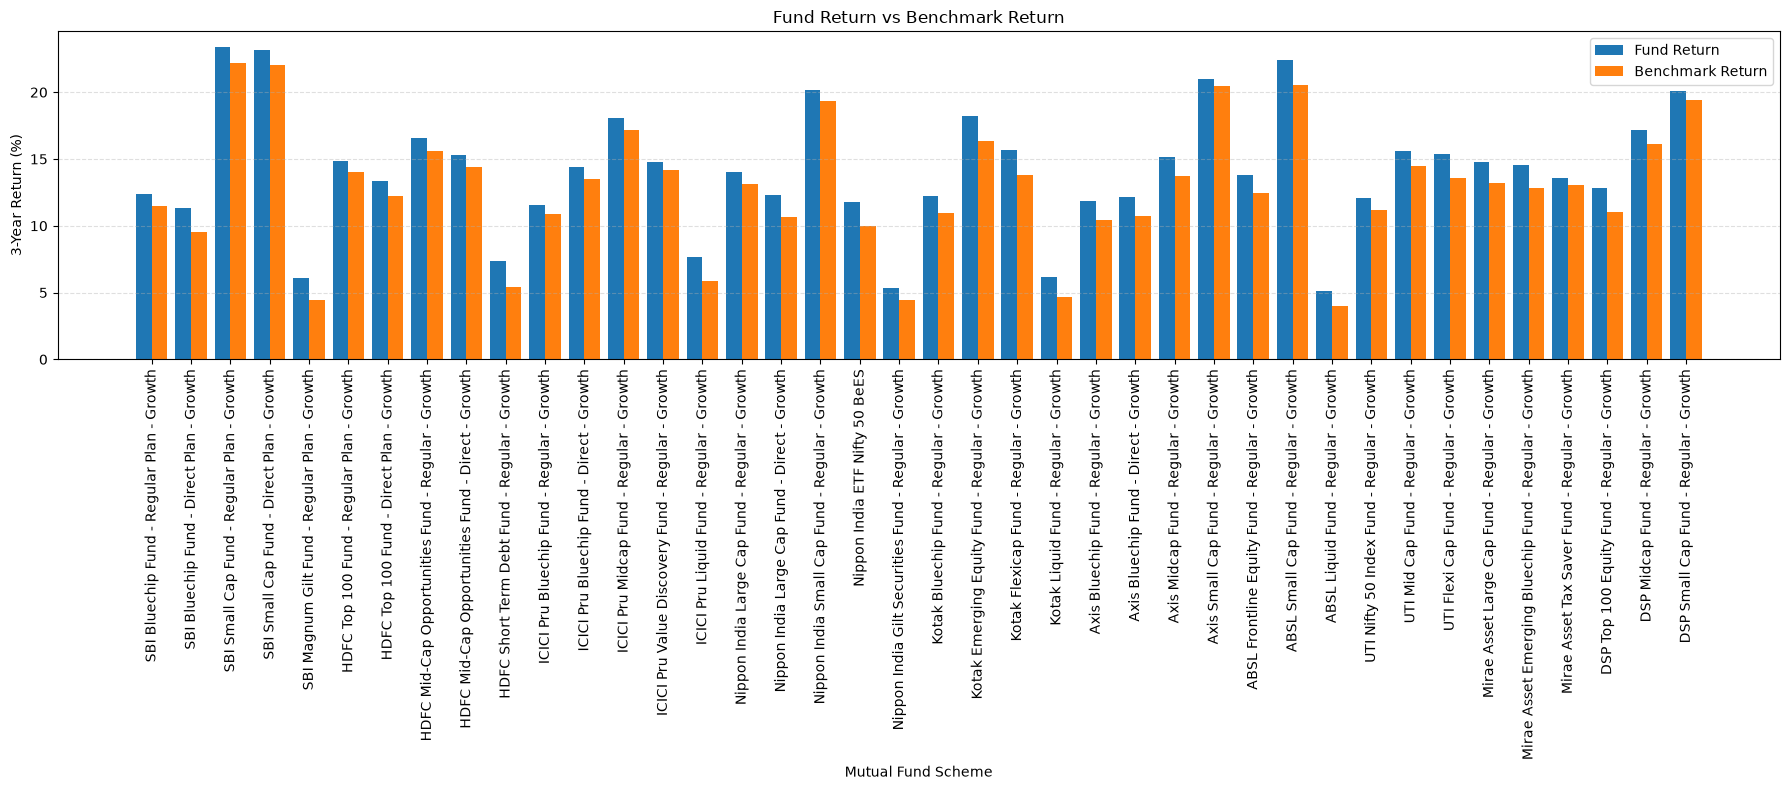

Benchmark Comparison Chart Created Successfully


In [39]:

# BENCHMARK COMPARISON

import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
performance = pd.read_csv(
    "../data/processed/07_scheme_performance_clean.csv"
)

# Select Columns
comparison = performance[
    [
        "scheme_name",
        "return_3yr_pct",
        "benchmark_3yr_pct"
    ]
]

# Create Figure
plt.figure(figsize=(18,8))

# X-axis positions
x = range(len(comparison))

# Width of bars
width = 0.4

# Fund Return Bars
plt.bar(
    [i - width/2 for i in x],
    comparison["return_3yr_pct"],
    width=width,
    label="Fund Return"
)

# Benchmark Bars
plt.bar(
    [i + width/2 for i in x],
    comparison["benchmark_3yr_pct"],
    width=width,
    label="Benchmark Return"
)

# X-axis Labels
plt.xticks(
    x,
    comparison["scheme_name"],
    rotation=90
)

# Axis Labels
plt.xlabel("Mutual Fund Scheme")

plt.ylabel("3-Year Return (%)")

# Title
plt.title("Fund Return vs Benchmark Return")

# Legend
plt.legend()

# Grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# Adjust Layout
plt.tight_layout()

# Save Chart
plt.savefig(
    "../dashboard/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

# Display
plt.show()

print("Benchmark Comparison Chart Created Successfully")